In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('/content/data.csv', encoding='ISO-8859-1')

print("Shape:", df.shape)
df.head()

Shape: (125339, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125339 entries, 0 to 125338
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    125339 non-null  object 
 1   StockCode    125339 non-null  object 
 2   Description  124994 non-null  object 
 3   Quantity     125338 non-null  float64
 4   InvoiceDate  125338 non-null  object 
 5   UnitPrice    125338 non-null  float64
 6   CustomerID   84465 non-null   float64
 7   Country      125338 non-null  object 
dtypes: float64(3), object(5)
memory usage: 7.7+ MB


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,345
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,40874
Country,1


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
cancelled_df = df[df['InvoiceNo'].astype(str).str.startswith('C')]
main_df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [8]:
main_df = main_df[main_df['Quantity'] > 0]

In [9]:
customer_df = main_df.dropna(subset=['CustomerID'])

In [10]:
main_df['Revenue'] = main_df['Quantity'] * main_df['UnitPrice']
customer_df['Revenue'] = customer_df['Quantity'] * customer_df['UnitPrice']

/tmp/ipykernel_10244/3628203254.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_df['Revenue'] = customer_df['Quantity'] * customer_df['UnitPrice']


In [11]:
customer_agg = customer_df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'
}).rename(columns={
    'Revenue': 'TotalRevenue',
    'InvoiceNo': 'TotalOrders'
})

customer_agg['AvgOrderValue'] = customer_agg['TotalRevenue'] / customer_agg['TotalOrders']
customer_agg.head()

,TotalRevenue,TotalOrders,AvgOrderValue
CustomerID,,,
12346.0,77183.60,1,77183.60
12347.0,1187.18,2,593.59
12348.0,1120.24,2,560.12
12350.0,334.40,1,334.40
12352.0,1401.48,4,350.37


In [12]:
country_agg = main_df.groupby('Country').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'
}).rename(columns={
    'Revenue': 'TotalRevenue',
    'InvoiceNo': 'OrderCount'
})

country_agg['RevenueShare (%)'] = 100 * country_agg['TotalRevenue'] / country_agg['TotalRevenue'].sum()
country_agg = country_agg.sort_values(by='TotalRevenue', ascending=False)
country_agg.head()

,TotalRevenue,OrderCount,RevenueShare (%)
Country,,,
United Kingdom,2051708.12,4299,84.440216
EIRE,63789.53,54,2.625326
Netherlands,58970.28,15,2.426984
Germany,49965.25,98,2.056373
Australia,41683.72,19,1.715538


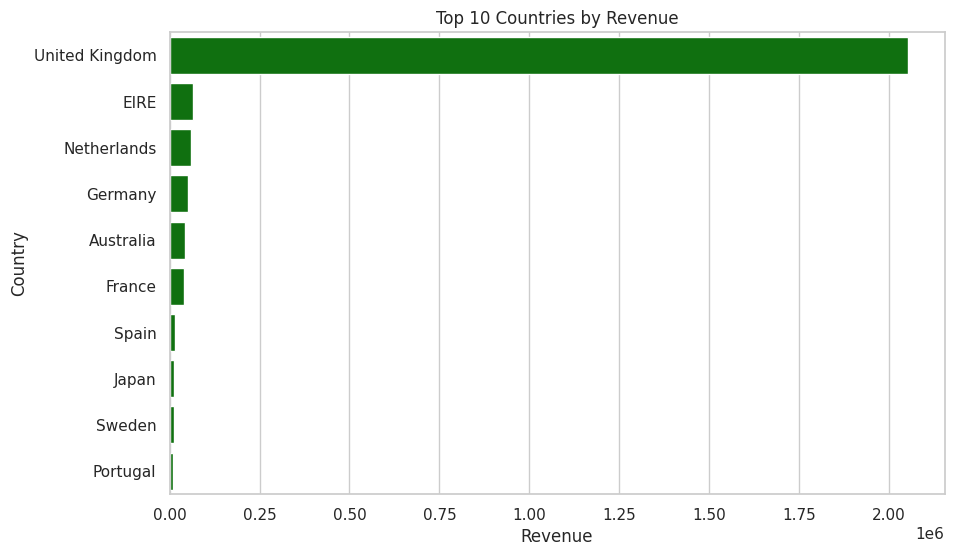

In [16]:
top_countries = country_agg.head(10)

sns.barplot(x=top_countries['TotalRevenue'], y=top_countries.index,color='green')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

In [17]:
main_df['Month'] = main_df['InvoiceDate'].dt.to_period('M')

monthly_revenue = main_df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

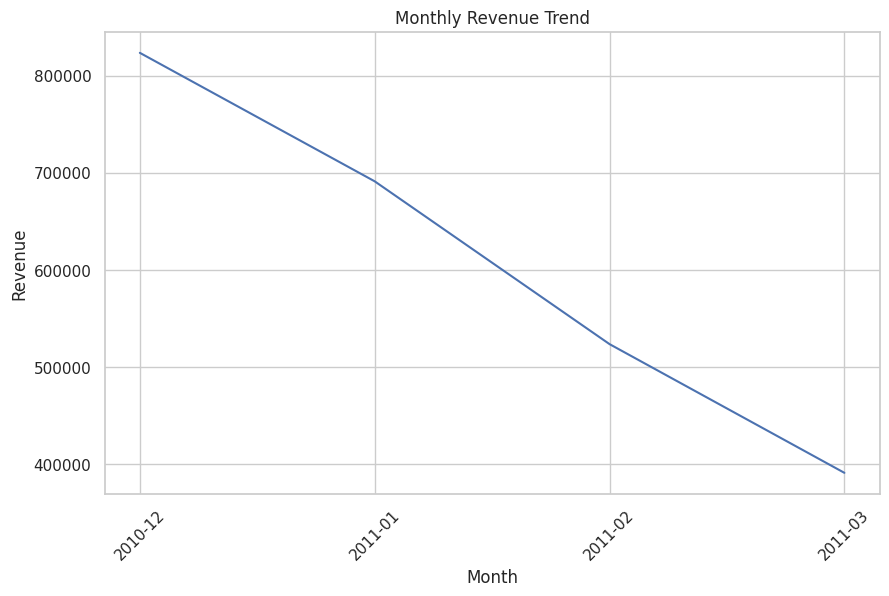

In [18]:
plt.plot(monthly_revenue['Month'], monthly_revenue['Revenue'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [19]:
top_products = main_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

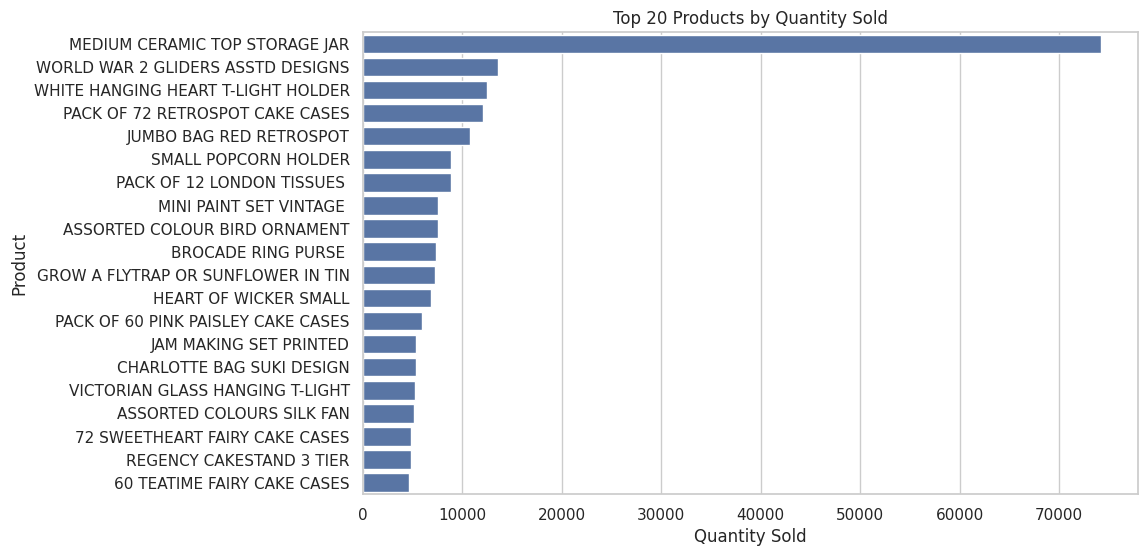

In [20]:
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 20 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

In [21]:
total_orders = df.groupby('Country')['InvoiceNo'].nunique()

cancelled_orders = cancelled_df.groupby('Country')['InvoiceNo'].nunique()

return_rate = (cancelled_orders / total_orders).fillna(0) * 100
return_rate = return_rate.sort_values(ascending=False)

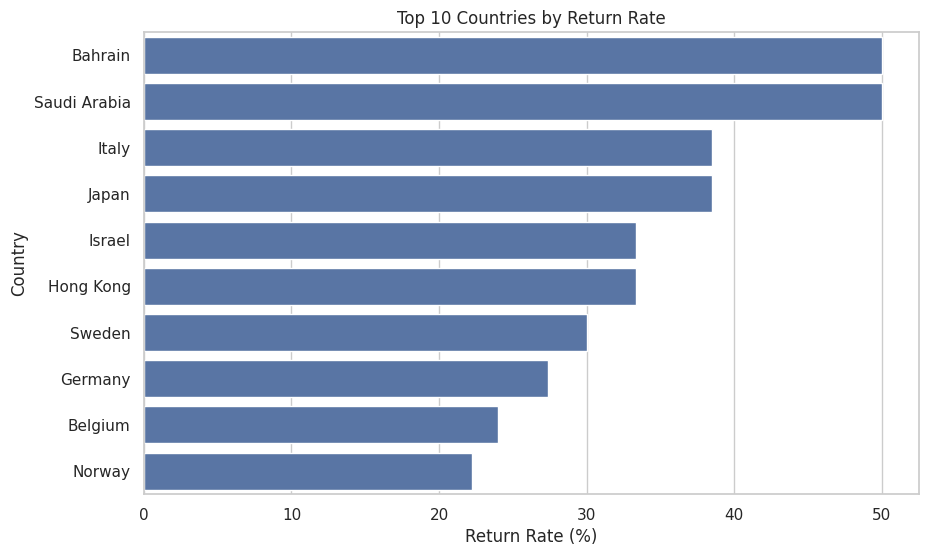

In [22]:
sns.barplot(x=return_rate.values[:10], y=return_rate.index[:10])
plt.title('Top 10 Countries by Return Rate')
plt.xlabel('Return Rate (%)')
plt.ylabel('Country')
plt.show()

In [30]:
top_customers = customer_agg.sort_values(by='TotalRevenue', ascending=False).head(10)
top_customers

,TotalRevenue,TotalOrders,AvgOrderValue
CustomerID,,,
12346.0,77183.60,1,77183.600000
14646.0,57866.02,10,5786.602000
18102.0,39766.09,7,5680.870000
12415.0,37842.74,4,9460.685000
14156.0,35496.87,13,2730.528462
15061.0,24470.82,23,1063.948696
15769.0,23181.48,8,2897.685000
15749.0,22998.40,2,11499.200000
17450.0,22748.74,6,3791.456667


/tmp/ipykernel_10244/2767484345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_customer_data['Month'] = top_customer_data['InvoiceDate'].dt.to_period('M')


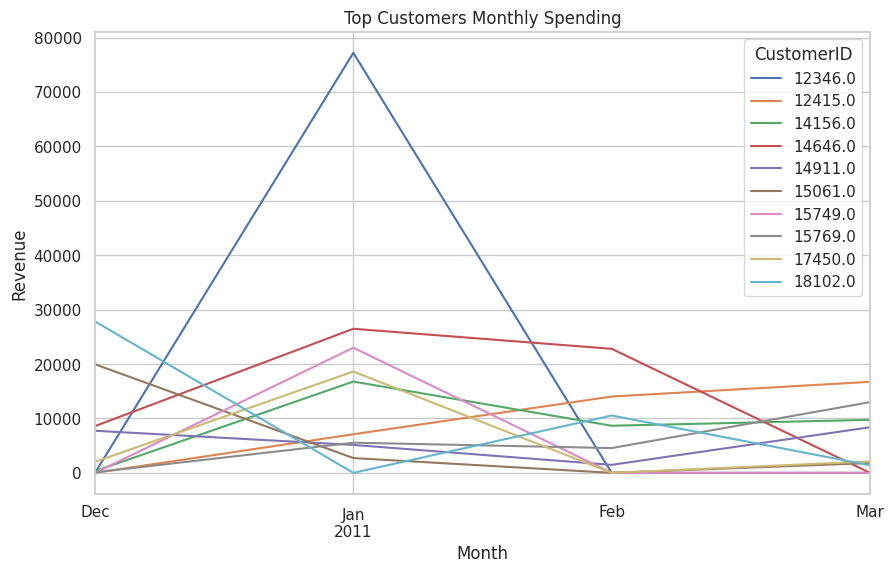

In [31]:
top_ids = top_customers.index

top_customer_data = customer_df[customer_df['CustomerID'].isin(top_ids)]
top_customer_data['Month'] = top_customer_data['InvoiceDate'].dt.to_period('M')

monthly_spend = top_customer_data.groupby(['CustomerID', 'Month'])['Revenue'].sum().unstack(fill_value=0)

monthly_spend.T.plot()
plt.title('Top Customers Monthly Spending')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [32]:
basket_size = main_df.groupby('InvoiceNo')['StockCode'].nunique()

avg_basket_size = basket_size.mean()
print("Average Basket Size:", avg_basket_size)

Average Basket Size: 25.580734139613835


In [33]:
basket_country = main_df.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique().reset_index()
basket_country_avg = basket_country.groupby('Country')['StockCode'].mean().sort_values(ascending=False)

basket_country_avg.head()

,StockCode
Country,
Singapore,56.000000
Lebanon,45.000000
Channel Islands,39.833333
Netherlands,35.000000
Cyprus,33.444444
